In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

from nilearn import datasets
from nilearn.maskers import NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure
from nilearn import image

In [7]:
pre_dir = Path("preprocessed")
atlas = "atlas/aal.nii"

masker = NiftiLabelsMasker(
    labels_img=atlas,
    standardize="zscore_sample"
)

connectome = ConnectivityMeasure(
    kind="correlation",
    standardize="zscore_sample"
)

In [10]:
fc_matrices = []
fc_vectors = []
subject_ids = []
skipped_ids = []
timepoint_info = []

for f in sorted(pre_dir.glob("*Filtered_4DVolume.nii")):
    sid = f.stem.replace("_Filtered_4DVolume", "")

    try:
        img = image.load_img(f)
        timepoint_info.append((sid, img.shape))

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            roi_ts = masker.fit_transform(img)

        if roi_ts.shape[1] != 116:
            skipped_ids.append(sid)
            continue

        fc = connectome.fit_transform([roi_ts])[0]

        iu = np.triu_indices_from(fc, k=1)
        vec = fc[iu]

        fc_matrices.append(fc)
        fc_vectors.append(vec)
        subject_ids.append(sid)

    except Exception as e:
        print(f"FAILED: {sid} -> {type(e).__name__}: {e}")
        skipped_ids.append(sid)

if len(fc_matrices) == 0:
    raise ValueError("No subjects passed ROI extraction with 116 regions.")

X_matrix = np.stack(fc_matrices)
X_vec = np.stack(fc_vectors)

print("Passed subjects:", len(subject_ids))
print("Skipped subjects:", len(skipped_ids))
print("X_matrix shape:", X_matrix.shape)
print("X_vec shape:", X_vec.shape)

print("\nSkipped subject IDs:")
if len(skipped_ids) == 0:
    print("None")
else:
    for sid in skipped_ids:
        print(sid)

y = []
for sid in subject_ids:
    if sid.startswith("sub-1"):
        y.append(0)   # control
    elif sid.startswith("sub-7"):
        y.append(1)   # ADHD
    else:
        raise ValueError(f"Unknown subject ID prefix: {sid}")

y = np.array(y, dtype=int)

print("\nTotal subjects:", len(y))
print("Control subjects:", np.sum(y == 0))
print("ADHD subjects:", np.sum(y == 1))

Passed subjects: 2
Skipped subjects: 0
X_matrix shape: (2, 116, 116)
X_vec shape: (2, 6670)

Skipped subject IDs:
None

Total subjects: 2
Control subjects: 1
ADHD subjects: 1


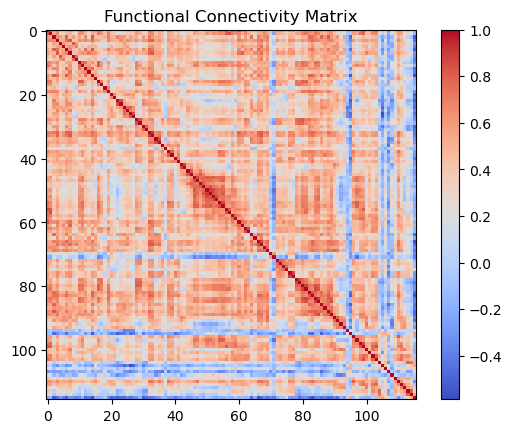

In [11]:
np.save("X_matrix.npy", X_matrix)
np.save("X_vec.npy", X_vec)
np.save("y.npy", y)
np.save("subject_ids.npy", np.array(subject_ids))
np.save("skipped_ids.npy", np.array(skipped_ids))

plt.imshow(X_matrix[0], cmap="coolwarm")
plt.colorbar()
plt.title("Functional Connectivity Matrix")
plt.show()